|          | First Name | Last Name | Signature (Full Name, Date) | Hours | Contribution % |
|----------|------------|-----------|-----------------------------|-------|----------------|
| Member 1: | Joey | Craig | Joey Craig, 2025-11-27 | 13 | 25% |
| Member 2: |  |  |  |  |
| Member 3: |  |  |  |  |  |
| Member 4: |  |  |  |  |  |


In [ ]:
import pandas as pd
import requests
from pathlib import Path
from PIL import Image
from io import BytesIO

In [ ]:
CSV_PATH = "bear_urls.csv"        # your CSV file name
OUT_DIR = Path("bears_labeled")   # main output folder
TIMEOUT = 10                      # seconds for HTTP timeout

In [ ]:
df = pd.read_csv(CSV_PATH)

In [ ]:
df.head()

,url,label
0,https://inaturalist-open-data.s3.amazonaws.com...,grizzly
1,https://inaturalist-open-data.s3.amazonaws.com...,grizzly
2,https://inaturalist-open-data.s3.amazonaws.com...,grizzly
3,https://inaturalist-open-data.s3.amazonaws.com...,grizzly
4,https://inaturalist-open-data.s3.amazonaws.com...,grizzly


In [ ]:
if "url" not in df.columns or "label" not in df.columns:
    raise ValueError("CSV must have columns named 'url' and 'label'")

In [ ]:
import pandas as pd

df = pd.read_csv(CSV_PATH)

# normalize headers: strip spaces + lowercase
df.columns = df.columns.str.strip().str.lower()

print([repr(c) for c in df.columns])  # optional: to see the cleaned names

["'url'", "'label'"]


In [ ]:
def normalize_label(lbl):
    return str(lbl).strip().lower().replace(" ", "_")

df["label_norm"] = df["label"].apply(normalize_label)

In [ ]:
OUT_DIR.mkdir(parents=True, exist_ok=True)

for lbl in df["label_norm"].unique():
    (OUT_DIR / lbl).mkdir(exist_ok=True)

In [ ]:
for idx, row in df.iterrows():
    url = row["url"]
    label_norm = row["label_norm"]

    if not isinstance(url, str) or not url.startswith("http"):
        print(f"[{idx}] Skipping invalid URL: {url!r}")
        continue

    try:
        # download
        resp = requests.get(url, timeout=TIMEOUT)
        resp.raise_for_status()

        # open and convert to RGB
        img = Image.open(BytesIO(resp.content)).convert("RGB")

        # choose a filename based on row index
        filename = f"img_{idx:06d}.jpg"
        out_path = OUT_DIR / label_norm / filename

        # save as JPEG
        img.save(out_path, "JPEG", quality=90)
        print(f"[{idx}] Saved -> {out_path}")

    except Exception as e:
        print(f"[{idx}] FAILED for URL={url!r}: {e}")

[0] Saved -> bears_labeled/grizzly/img_000000.jpg
[1] Saved -> bears_labeled/grizzly/img_000001.jpg
[2] Saved -> bears_labeled/grizzly/img_000002.jpg
[3] Saved -> bears_labeled/grizzly/img_000003.jpg
[4] Saved -> bears_labeled/grizzly/img_000004.jpg
[5] Saved -> bears_labeled/grizzly/img_000005.jpg
[6] Saved -> bears_labeled/grizzly/img_000006.jpg
[7] Saved -> bears_labeled/grizzly/img_000007.jpg
[8] Saved -> bears_labeled/grizzly/img_000008.jpg
[9] Saved -> bears_labeled/grizzly/img_000009.jpg
[10] Saved -> bears_labeled/grizzly/img_000010.jpg
[11] Saved -> bears_labeled/grizzly/img_000011.jpg
[12] Saved -> bears_labeled/grizzly/img_000012.jpg
[13] Saved -> bears_labeled/grizzly/img_000013.jpg
[14] Saved -> bears_labeled/grizzly/img_000014.jpg
[15] Saved -> bears_labeled/grizzly/img_000015.jpg
[16] Saved -> bears_labeled/grizzly/img_000016.jpg
[17] Saved -> bears_labeled/grizzly/img_000017.jpg
[18] Saved -> bears_labeled/grizzly/img_000018.jpg
[19] Saved -> bears_labeled/grizzly/img_0

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import torch.nn.functional as F

In [ ]:
root = Path("bears_labeled")

for cls in root.iterdir():
    if cls.is_dir():
        n = len(list(cls.glob("*.jpg")))
        print(cls.name, "->", n, "images")

grizzly -> 1010 images
black_bear -> 999 images


In [ ]:
data_dir = "bears_labeled"

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [ ]:
full_dataset = datasets.ImageFolder(data_dir, transform=train_transform)
print("Classes:", full_dataset.classes)
# should be ['black_bear', 'grizzly']

# if you had an 'unknown' class, we'd filter here; but you don't, so:
dataset = full_dataset

val_frac = 0.2
val_size = int(len(dataset) * val_frac)
train_size = len(dataset) - val_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# attach proper transforms
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

Classes: ['black_bear', 'grizzly']


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# load pretrained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# replace final layer with Dropout + Linear(…, 2)
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_ftrs, 2)
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

Using device: cpu
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 71.6MB/s]


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def eval_one_epoch(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [ ]:
num_epochs = 6

tweaked_train_losses, tweaked_val_losses = [], []
tweaked_train_accs, tweaked_val_accs = [], []
best_val_acc = 0.0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc     = eval_one_epoch(model, val_loader, criterion)

    tweaked_train_losses.append(train_loss)
    tweaked_val_losses.append(val_loss)
    tweaked_train_accs.append(train_acc)
    tweaked_val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} "
          f"- train_loss: {train_loss:.4f}, train_acc: {train_acc:.3f} "
          f"- val_loss: {val_loss:.4f}, val_acc: {val_acc:.3f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "bear_resnet18_best.pth")
        print("  --> saved new best model")

Epoch 1/6 - train_loss: 0.3633, train_acc: 0.829 - val_loss: 0.2248, val_acc: 0.903
  --> saved new best model
Epoch 2/6 - train_loss: 0.0986, train_acc: 0.970 - val_loss: 0.2551, val_acc: 0.903
Epoch 3/6 - train_loss: 0.0347, train_acc: 0.993 - val_loss: 0.2530, val_acc: 0.913
  --> saved new best model
Epoch 4/6 - train_loss: 0.0135, train_acc: 0.998 - val_loss: 0.2408, val_acc: 0.918
  --> saved new best model
Epoch 5/6 - train_loss: 0.0089, train_acc: 0.999 - val_loss: 0.2402, val_acc: 0.915
Epoch 6/6 - train_loss: 0.0036, train_acc: 1.000 - val_loss: 0.2465, val_acc: 0.915


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import torch.nn.functional as F

# Ensure we're using the final model on the right device
model.to(device)
model.eval()

# ----- predictions on validation set -----
all_labels, all_preds = [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs)
        preds = outputs.argmax(1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print("Confusion matrix:")
print(cm)

# class names from ImageFolder
base_ds = dataset
idx_to_class = {v: k for k, v in base_ds.class_to_idx.items()}
class_names = [idx_to_class[i] for i in sorted(idx_to_class.keys())]

print("\nClassification report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# per-class accuracy
class_acc = cm.diagonal() / cm.sum(axis=1)
print("\nPer-class accuracy:")
for name, acc in zip(class_names, class_acc):
    print(f"{name}: {acc:.3f}")

Confusion matrix:
[[193  15]
 [ 18 175]]

Classification report:
              precision    recall  f1-score   support

  black_bear       0.91      0.93      0.92       208
     grizzly       0.92      0.91      0.91       193

    accuracy                           0.92       401
   macro avg       0.92      0.92      0.92       401
weighted avg       0.92      0.92      0.92       401


Per-class accuracy:
black_bear: 0.928
grizzly: 0.907


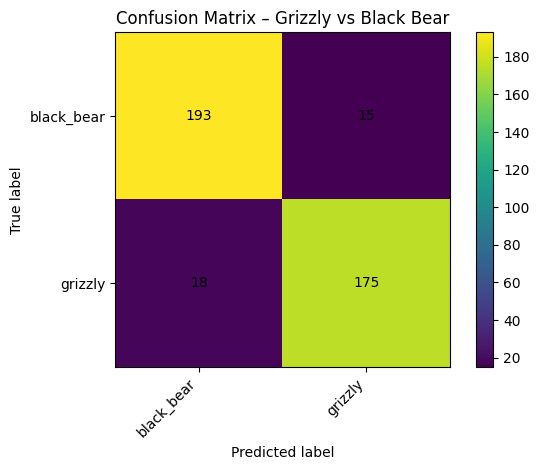

In [ ]:
fig, ax = plt.subplots()
im = ax.imshow(cm)

ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix – Grizzly vs Black Bear")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("confusion_matrix_bears.png", dpi=300, bbox_inches="tight")
plt.show()

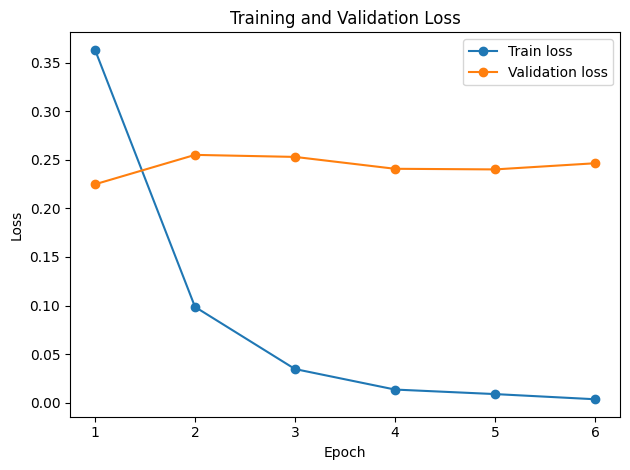

In [ ]:
epochs = range(1, len(tweaked_train_losses) + 1)

plt.figure()
plt.plot(epochs, tweaked_train_losses, marker="o", label="Train loss")
plt.plot(epochs, tweaked_val_losses, marker="o", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig("loss_curves_bears.png", dpi=300, bbox_inches="tight")
plt.show()

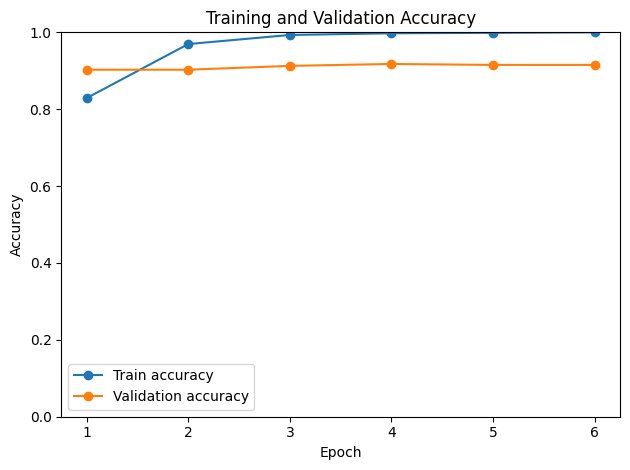

In [ ]:
epochs = range(1, len(tweaked_train_accs) + 1)

plt.figure()
plt.plot(epochs, tweaked_train_accs, marker="o", label="Train accuracy")
plt.plot(epochs, tweaked_val_accs, marker="o", label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1.0)
plt.title("Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("accuracy_curves_bears.png", dpi=300, bbox_inches="tight")
plt.show()

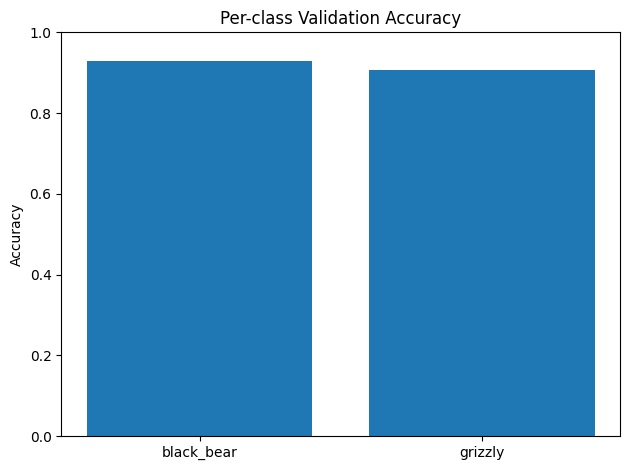

In [ ]:
import numpy as np

x = np.arange(len(class_names))

plt.figure()
plt.bar(x, class_acc)
plt.xticks(x, class_names)
plt.ylim(0, 1.0)
plt.ylabel("Accuracy")
plt.title("Per-class Validation Accuracy")
plt.tight_layout()
plt.savefig("per_class_accuracy_bars.png", dpi=300, bbox_inches="tight")
plt.show()

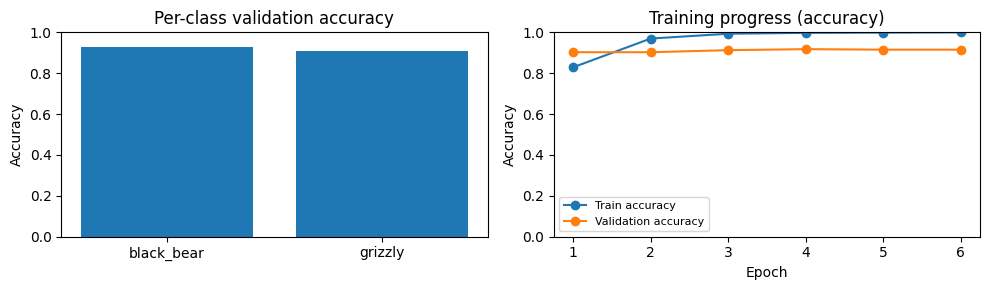

In [ ]:
# bar+line combined
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# left: per-class bar (using class_acc, class_names from earlier)
x = np.arange(len(class_names))
ax0 = axes[0]
ax0.bar(x, class_acc)
ax0.set_xticks(x)
ax0.set_xticklabels(class_names)
ax0.set_ylim(0, 1.0)
ax0.set_ylabel("Accuracy")
ax0.set_title("Per-class validation accuracy")

# right: accuracy over epochs
epochs = range(1, len(tweaked_train_accs) + 1)
ax1 = axes[1]
ax1.plot(epochs, tweaked_train_accs, marker="o", label="Train accuracy")
ax1.plot(epochs, tweaked_val_accs, marker="o", label="Validation accuracy")
ax1.set_ylim(0, 1.0)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.set_title("Training progress (accuracy)")
ax1.legend(fontsize=8)

plt.tight_layout()
plt.savefig("accuracy_bar_and_line_bears.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import torch.nn.functional as F

# Ensure model is on device
model.to(device)
model.eval()

# ---- predictions on validation set ----
all_labels, all_preds = [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs)
        preds = outputs.argmax(1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print("Confusion matrix:")
print(cm)

# raw class names from ImageFolder (e.g. ['black_bear', 'grizzly'])
base_ds = dataset
idx_to_class = {v: k for k, v in base_ds.class_to_idx.items()}
class_names = [idx_to_class[i] for i in sorted(idx_to_class.keys())]
print("\nRaw class_names:", class_names)

# --- pretty name mapping ---
pretty_map = {"black_bear": "Black Bear",
    "grizzly": "Grizzly Bear".}
pretty_names = [pretty_map[name] for name in class_names]
print("Pretty names:", pretty_names)

# index -> pretty label (for titles in example images)
idx_to_pretty = {i: pretty_names[i] for i in range(len(pretty_names))}

# per-class accuracy
class_acc = cm.diagonal() / cm.sum(axis=1)
print("\nPer-class accuracy:")
for name, acc in zip(pretty_names, class_acc):
    print(f"{name}: {acc:.3f}")

print("\nClassification report:")
print(classification_report(all_labels, all_preds, target_names=pretty_names))

Confusion matrix:
[[193  15]
 [ 18 175]]

Raw class_names: ['black_bear', 'grizzly']
Pretty names: ['Black Bear', 'Grizzly Bear']

Per-class accuracy:
Black Bear: 0.928
Grizzly Bear: 0.907

Classification report:
              precision    recall  f1-score   support

  Black Bear       0.91      0.93      0.92       208
Grizzly Bear       0.92      0.91      0.91       193

    accuracy                           0.92       401
   macro avg       0.92      0.92      0.92       401
weighted avg       0.92      0.92      0.92       401



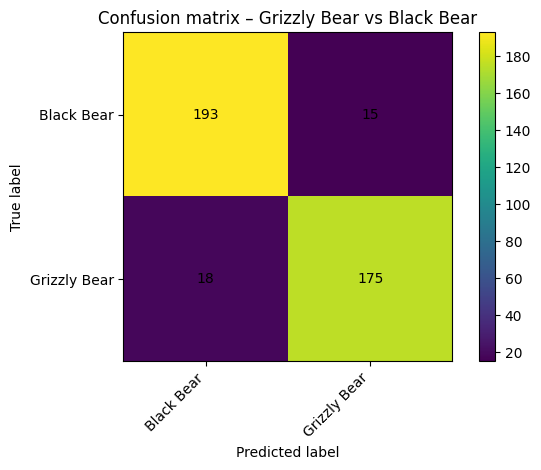

In [ ]:
fig, ax = plt.subplots()
im = ax.imshow(cm)

ax.set_xticks(range(len(pretty_names)))
ax.set_yticks(range(len(pretty_names)))
ax.set_xticklabels(pretty_names, rotation=45, ha="right")
ax.set_yticklabels(pretty_names)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion matrix – Grizzly Bear vs Black Bear")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("confusion_matrix_bears.png", dpi=300, bbox_inches="tight")
plt.show()

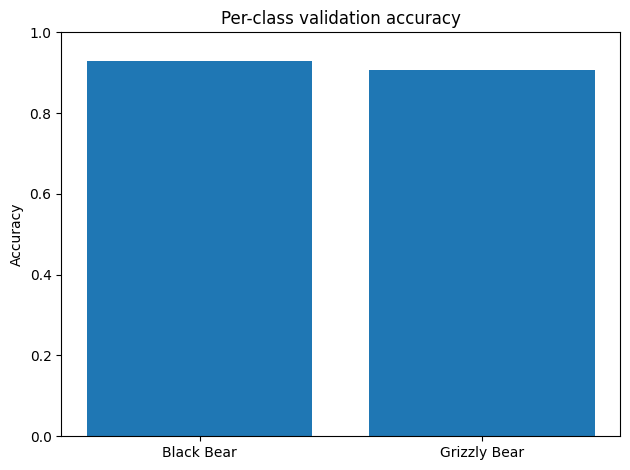

In [ ]:
x = np.arange(len(pretty_names))

plt.figure()
plt.bar(x, class_acc)
plt.xticks(x, pretty_names)
plt.ylim(0, 1.0)
plt.ylabel("Accuracy")
plt.title("Per-class validation accuracy")
plt.tight_layout()
plt.savefig("per_class_accuracy_bars.png", dpi=300, bbox_inches="tight")
plt.show()

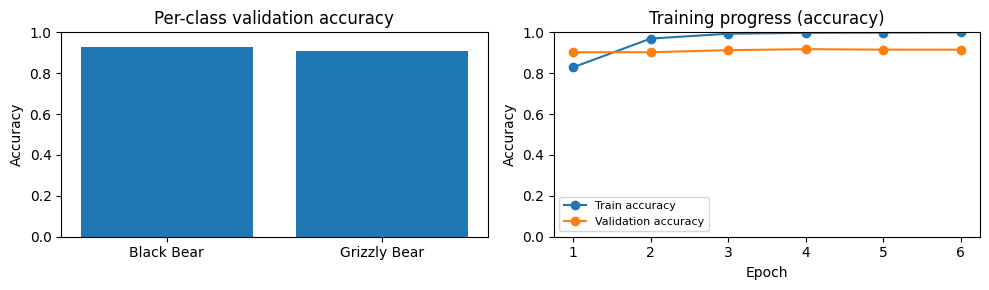

In [ ]:
# if your lists are called tweaked_*:
train_accs = tweaked_train_accs
val_accs   = tweaked_val_accs

epochs = range(1, len(train_accs) + 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# LEFT: per-class accuracy bar chart
ax0 = axes[0]
x = np.arange(len(pretty_names))
ax0.bar(x, class_acc)
ax0.set_xticks(x)
ax0.set_xticklabels(pretty_names)
ax0.set_ylim(0, 1.0)
ax0.set_ylabel("Accuracy")
ax0.set_title("Per-class validation accuracy")

# RIGHT: accuracy over epochs
ax1 = axes[1]
ax1.plot(epochs, train_accs, marker="o", label="Train accuracy")
ax1.plot(epochs, val_accs, marker="o", label="Validation accuracy")
ax1.set_ylim(0, 1.0)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.set_title("Training Progress (Accuracy)")
ax1.legend(fontsize=8)

plt.tight_layout()
plt.savefig("accuracy_bar_and_line_bears.png", dpi=300, bbox_inches="tight")
plt.show()

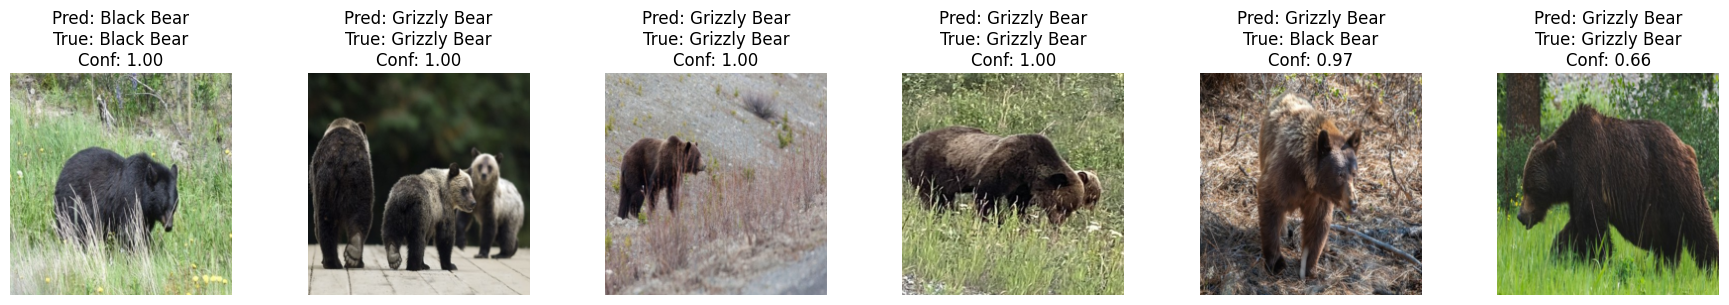

In [ ]:
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def show_example_grid(num_images=6):
    model.eval()
    imgs_batch, labels_batch = next(iter(val_loader))
    imgs_batch = imgs_batch.to(device)
    labels_batch = labels_batch.to(device)

    with torch.no_grad():
        outputs = model(imgs_batch)
        probs = F.softmax(outputs, dim=1)
        preds = outputs.argmax(1)

    fig, axes = plt.subplots(1, num_images, figsize=(3*num_images, 3))

    for i in range(num_images):
        img = imgs_batch[i].cpu()
        img_disp = img * std + mean
        img_disp = img_disp.clamp(0, 1)

        true_label = idx_to_pretty[int(labels_batch[i].cpu())]
        pred_label = idx_to_pretty[int(preds[i].cpu())]
        conf = probs[i][preds[i]].item()

        ax = axes[i]
        ax.imshow(img_disp.permute(1, 2, 0))
        ax.axis("off")
        ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}\nConf: {conf:.2f}")

    plt.tight_layout()
    plt.savefig("example_predictions_bears.png", dpi=300, bbox_inches="tight")
    plt.show()

show_example_grid()

In [ ]:
print(dataset.class_to_idx)

{'black_bear': 0, 'grizzly': 1}


In [ ]:
import numpy as np

# class index -> raw name (e.g. 0 -> 'black_bear')
idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}
class_names = [idx_to_class[i] for i in sorted(idx_to_class.keys())]

# optional: pretty names
pretty_map = {
    "black_bear": "Black Bear",
    "grizzly": "Grizzly Bear",
}
pretty_names = [pretty_map[name] for name in class_names]

# count labels that actually appear in the validation loader
val_counts = np.zeros(len(class_names), dtype=int)

for _, labels in val_loader:
    labels = labels.cpu().numpy()
    vals, cts = np.unique(labels, return_counts=True)
    for v, c in zip(vals, cts):
        val_counts[v] += c

print("Validation set counts:")
for i, count in enumerate(val_counts):
    print(f"{pretty_names[i]}: {count}")

Validation set counts:
Black Bear: 208
Grizzly Bear: 193


In [ ]:
all_labels_full = [label for _, label in dataset]  # or full_dataset if you used that name
vals, cts = np.unique(all_labels_full, return_counts=True)

print("Full dataset counts:")
for v, c in zip(vals, cts):
    print(f"{pretty_names[v]}: {c}")

Full dataset counts:
Black Bear: 999
Grizzly Bear: 1010


In [ ]:
imgs_batch, labels_batch = next(iter(val_loader))

In [ ]:
import random
import torch.nn.functional as F

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def show_example_grid_random(num_images=6):
    model.eval()

    # choose random indices from the validation set
    indices = random.sample(range(len(val_dataset)), num_images)

    fig, axes = plt.subplots(1, num_images, figsize=(3 * num_images, 3))

    for ax, idx in zip(axes, indices):
        # get one (image, label) from the val split
        img, label = val_dataset[idx]   # img already has val_transform

        # run prediction
        with torch.no_grad():
            x = img.unsqueeze(0).to(device)  # add batch dim
            outputs = model(x)
            probs = F.softmax(outputs, dim=1)[0]
            pred_idx = int(torch.argmax(probs))
            conf = probs[pred_idx].item()

        # un-normalize for display
        img_disp = img * std + mean
        img_disp = img_disp.clamp(0, 1)

        true_label = idx_to_pretty[int(label)]
        pred_label = idx_to_pretty[pred_idx]

        ax.imshow(img_disp.permute(1, 2, 0))
        ax.axis("off")
        ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}\nConf: {conf:.2f}")

    plt.tight_layout()
    plt.savefig("example_predictions_bears_random.png", dpi=300, bbox_inches="tight")
    plt.show()

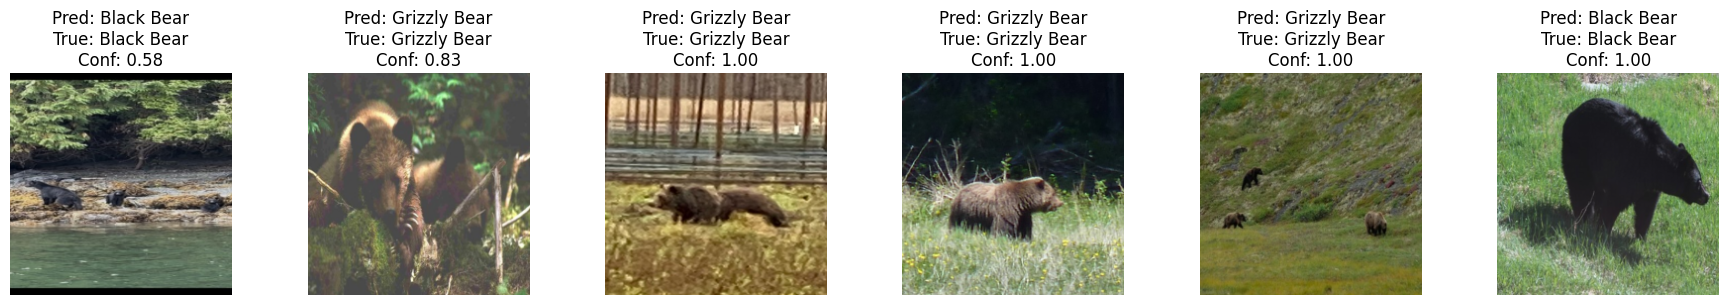

In [ ]:
show_example_grid_random(num_images=6)

In [ ]:
import torch
import torch.nn.functional as F

misclassified = []

model.eval()
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs)
        probs = F.softmax(outputs, dim=1)
        preds = probs.argmax(1)

        # boolean mask of wrong predictions
        wrong = preds != labels

        for i in range(imgs.size(0)):
            if wrong[i]:
                misclassified.append((
                    imgs[i].cpu(),                 # image tensor (normalized)
                    int(labels[i].cpu()),          # true class index
                    int(preds[i].cpu()),           # predicted class index
                    float(probs[i][preds[i]])      # confidence for predicted class
                ))

print(f"Found {len(misclassified)} misclassified validation images.")

Found 33 misclassified validation images.


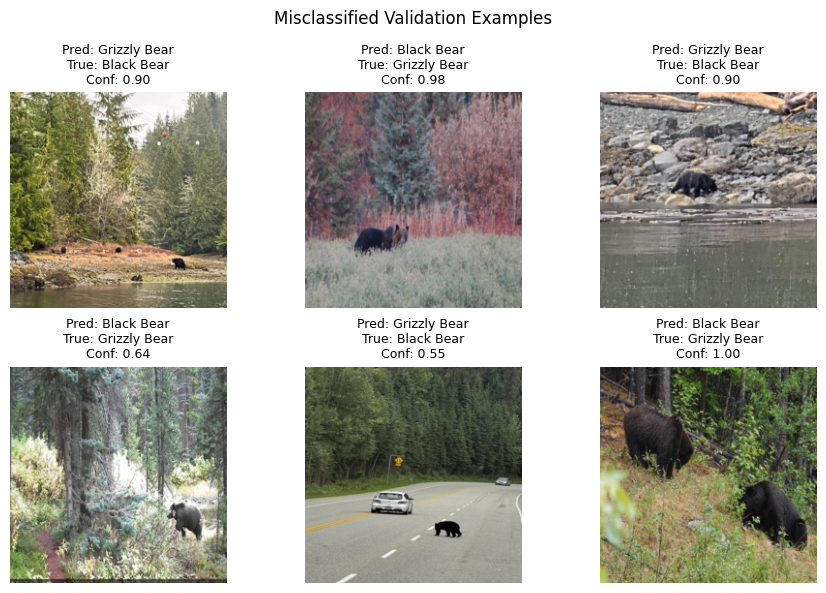

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

def show_misclassified_grid(num_images=6, rows=2, cols=3):
    if len(misclassified) == 0:
        print("No misclassified examples in the validation set!")
        return

    num_images = min(num_images, len(misclassified))

    # randomly choose misclassified examples to show
    selected = random.sample(misclassified, num_images) \
        if len(misclassified) > num_images else misclassified

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))

    # flatten axes for easy iteration
    axes = axes.flatten()

    for ax, (img, true_idx, pred_idx, conf) in zip(axes, selected):
        # un-normalize for display
        img_disp = img * std + mean
        img_disp = img_disp.clamp(0, 1)

        true_label = idx_to_pretty[true_idx]
        pred_label = idx_to_pretty[pred_idx]

        ax.imshow(img_disp.permute(1, 2, 0))
        ax.axis("off")
        ax.set_title(
            f"Pred: {pred_label}\nTrue: {true_label}\nConf: {conf:.2f}",
            fontsize=9
        )

    # turn off any leftover empty axes (if < rows*cols images)
    for ax in axes[num_images:]:
        ax.axis("off")

    plt.suptitle("Misclassified Validation Examples", fontsize=12)
    plt.tight_layout()
    plt.savefig("misclassified_examples_bears.png", dpi=300, bbox_inches="tight")
    plt.show()

show_misclassified_grid()